# Simon's Algorithm, A Hands-On Notebook

### Education Series · Quantum Computing · Trinexis

> **Course thesis:** *Indistinguishable alternatives interfere; probabilities are squared magnitudes of amplitudes.*
> Simon's algorithm is the cleanest illustration of this idea in the whole course. Two different inputs that produce the **same** output become *indistinguishable*, so their amplitudes **interfere**, and that interference is precisely what leaks the hidden secret.

---

## What we will learn

1. **The Simon problem**, a black-box (oracle) promise problem, and *why it is hard for a classical computer*.
2. **The quantum algorithm**, built from scratch in NumPy so you can *see the interference* in the amplitudes.
3. **The classical post-processing**, recovering the secret string by solving a linear system over $\mathrm{GF}(2)$ (arithmetic mod 2).
4. **Worked cases** for **$n=1$, $n=2$, and $n=3$** qubits, including the degenerate 1-qubit warm-up.
5. **A Qiskit implementation** of the same circuit, run on the Aer simulator (ideal *and* noisy).
6. **Exercises and an interactive playground** so you can experiment on your own afterwards.

## The one-line summary
> Prepare a uniform superposition, query the oracle, and apply Hadamards again. Destructive interference **kills every string $z$ with $z\cdot s = 1$**, so each measurement hands you a random equation $z\cdot s \equiv 0 \pmod 2$. Collect $n-1$ independent equations, solve for $s$. Cost: **$O(n)$ oracle queries** vs. the **$\Omega(2^{n/2})$** any classical algorithm needs.

---
*How to use this notebook:* run the cells top-to-bottom (in Colab: `Runtime ▸ Run all`, or `Shift+Enter` cell by cell). Every function is documented; the exercises at the end have collapsible solutions. Then change the secret strings and qubit counts and watch what happens.

## 0 · Setup

Foundational cells use **NumPy + Matplotlib** only. The framework section uses **Qiskit 2.5.0** and **qiskit-aer 0.17.2**. The cell below installs them *only if missing* (so it is fast on re-runs and works both in Google Colab and locally).

In [1]:
# --- Dependencies (installs Qiskit/Aer only if they are not already present) ---
try:
    import qiskit, qiskit_aer  # noqa: F401
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "qiskit==2.5.0", "qiskit-aer==0.17.2"])
    import qiskit, qiskit_aer  # noqa: F401
print("Qiskit", qiskit.__version__, "| qiskit-aer", qiskit_aer.__version__)

Qiskit 2.5.0 | qiskit-aer 0.17.2


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Reproducibility (course convention)
np.random.seed(42)
RNG = np.random.default_rng(42)

# Plot styling
plt.rcParams.update({"figure.figsize": (6.2, 3.4), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 11})
print("NumPy", np.__version__, "| ready.")

NumPy 2.0.2 | ready.


## 1 · The Simon Problem

We are given a function that we can only use as a **black box** (an *oracle*):
$$ f : \{0,1\}^n \;\longrightarrow\; \{0,1\}^n . $$
We are **promised** that there is a fixed secret string $s \in \{0,1\}^n$ such that, for all inputs $x,y$,
$$ f(x) = f(y) \quad\Longleftrightarrow\quad y = x \oplus s , $$
where $\oplus$ is bitwise XOR (addition mod 2).

**Two flavours of the promise:**

* **$s \neq 0$**, the function is **two-to-one**. Inputs come in pairs $\{x,\; x\oplus s\}$ that collide (map to the same output). The pair $\{x, x\oplus s\}$ is a *coset* of the subgroup $\{0, s\}$.
* **$s = 0^n$**, the function is **one-to-one** (a permutation); there is no hidden period.

**The task:** find $s$ using as few oracle queries as possible.

### A tiny example ($n=3$, $s=110$)
Inputs $x$ and $x\oplus 110$ share an output. E.g. $001$ and $111$ collide; $000$ and $110$ collide; and so on, eight inputs fold into four outputs.

### Why this is *hard* classically
A classical algorithm learns nothing until it finds a **collision**, two inputs $x\neq y$ with $f(x)=f(y)$ (which then reveals $s = x\oplus y$). Because outputs look random, finding a collision is a birthday-style search: you must query roughly $\Omega(2^{n/2})$ inputs before two of them are likely to land in the same coset. This is **exponential in $n$**.

Simon's quantum algorithm needs only **$O(n)$** oracle queries. Historically this was the **first provable exponential separation** between quantum and classical query complexity, and it directly inspired Shor's factoring algorithm (both are *hidden-subgroup / period-finding* problems).

## 2 · The Quantum Algorithm, where the interference lives

Use **two $n$-qubit registers**: an *input* register and an *output* register, starting in $|0\rangle_{\text{in}}|0\rangle_{\text{out}}$.

**Step 1, Superposition.** Apply $H^{\otimes n}$ to the input register:
$$ \frac{1}{\sqrt{N}}\sum_{x\in\{0,1\}^n} |x\rangle\,|0\rangle , \qquad N = 2^n . $$

**Step 2, Query the oracle** $U_f:|x\rangle|y\rangle \mapsto |x\rangle|y\oplus f(x)\rangle$:
$$ \frac{1}{\sqrt{N}}\sum_{x} |x\rangle\,|f(x)\rangle . $$
Now the input register is *entangled* with the output. Two inputs $x_0$ and $x_0\oplus s$ carry the **same** output label $f(x_0)$, they have become **indistinguishable**.

**Step 3, Hadamard again** on the input register. Using $H^{\otimes n}|x\rangle = \frac{1}{\sqrt N}\sum_z (-1)^{x\cdot z}|z\rangle$:
$$ \frac{1}{N}\sum_{x}\sum_{z} (-1)^{x\cdot z}\,|z\rangle\,|f(x)\rangle . $$

**Step 4, Read the amplitude.** For an output value $w$ in the image of $f$, the inputs mapping to it are exactly the coset $\{x_0,\,x_0\oplus s\}$. The amplitude of $|z\rangle|w\rangle$ is
$$ \frac{1}{N}\Big[(-1)^{x_0\cdot z} + (-1)^{(x_0\oplus s)\cdot z}\Big]
   = \frac{(-1)^{x_0\cdot z}}{N}\Big[\,1 + (-1)^{\,s\cdot z}\,\Big]. $$

This bracket is the whole story:

$$ 1 + (-1)^{s\cdot z} = \begin{cases} 2 & \text{if } s\cdot z \equiv 0 \pmod 2 \quad(\textbf{constructive}) \\[2pt] 0 & \text{if } s\cdot z \equiv 1 \pmod 2 \quad(\textbf{destructive}) \end{cases} $$

**Step 5, Measure the input register.** Every outcome $z$ you can possibly see satisfies
$$ \boxed{\;z\cdot s \equiv 0 \pmod 2\;} $$
and the allowed $z$ are **uniform** over that $(n-1)$-dimensional subspace. One run = one random linear equation about $s$.

> **This is the course thesis in action.** Because $x_0$ and $x_0\oplus s$ produce the *same* output, *which one happened is indistinguishable*, so their amplitudes are added and interfere. The interference erases exactly the strings $z$ with $z\cdot s=1$, engraving the secret into the measurement statistics.

**Step 6, Solve.** Repeat to gather $n-1$ **linearly independent** equations $z_i\cdot s = 0$; then solve the linear system over $\mathrm{GF}(2)$ for the unique non-zero $s$. (If instead the equations ever span the *full* $n$-dimensional space, the function was one-to-one and $s=0^n$.)

## 3 · The reusable toolkit

We first build everything **from scratch in NumPy**, so nothing is hidden behind a framework. These helpers follow the course's bit convention:

* Bit strings are stored **LSB-first**: `bits[j]` is the bit of weight $2^j$, i.e. the value on *qubit $j$*.
* `int_to_bits` / `bits_to_int` convert between an integer and this array form.

In [3]:
# ---- Bit helpers (LSB-first: bits[j] has weight 2**j = qubit j) ----
def int_to_bits(v, n):
    '''Integer -> length-n array of bits, LSB-first (bits[j] = qubit j).'''
    return np.array([(v >> j) & 1 for j in range(n)], dtype=int)

def bits_to_int(bits):
    '''Length-n bit array (LSB-first) -> integer.'''
    return int(sum(int(b) << j for j, b in enumerate(bits)))

def parity(x):
    '''Parity (XOR of all bits) of a non-negative integer.'''
    return bin(x).count("1") & 1

def dot_mod2(a, b):
    '''Bitwise dot product mod 2 of two integers: a . b (mod 2).'''
    return parity(a & b)

# quick sanity checks
assert bits_to_int(int_to_bits(6, 3)) == 6
assert dot_mod2(0b110, 0b010) == 1 and dot_mod2(0b110, 0b001) == 0
print("bit helpers OK  |  6 ->", int_to_bits(6, 3), "(LSB-first)")

bit helpers OK  |  6 -> [0 1 1] (LSB-first)


### 3.1 · Building an oracle with a chosen secret

To *test* the algorithm we construct functions whose secret we already know. `make_simon_function(s, n)` returns a lookup table `f` with `f[x] == f[x ^ s]`:

* it walks through inputs; for each not-yet-assigned $x$ it hands a fresh output label to the whole coset $\{x, x\oplus s\}$;
* if `s == 0` every input gets its own label (one-to-one);
* labels are shuffled so the outputs look scrambled, exactly as an opaque oracle would.

In [4]:
def make_simon_function(s, n, rng=RNG):
    '''Lookup table f: {0,1}^n -> {0,1}^n with f[x] == f[x ^ s].
    s != 0 gives a two-to-one function; s == 0 gives a one-to-one function.'''
    N = 2 ** n
    f = -np.ones(N, dtype=int)
    labels = list(range(N))
    rng.shuffle(labels)          # scramble outputs so f looks opaque
    idx = 0
    for x in range(N):
        if f[x] == -1:
            val = labels[idx]; idx += 1
            f[x] = val
            f[x ^ s] = val        # coset {x, x^s} shares one label (x^0 == x)
    return f

def verify_function(f, s, n):
    '''Assert the Simon promise holds for this table.'''
    for x in range(2 ** n):
        assert f[x] == f[x ^ s], "promise f(x)=f(x^s) violated!"
    counts = Counter(f.tolist())
    if s == 0:
        assert all(v == 1 for v in counts.values()), "s=0 must be one-to-one"
    else:
        assert all(v == 2 for v in counts.values()), "s!=0 must be two-to-one"
    return True

print("oracle builder ready.")

oracle builder ready.


In [5]:
# --- Peek at a concrete oracle: n = 3, secret s = 110 (binary) = 6 ---
n_demo, s_demo = 3, 0b110
f_demo = make_simon_function(s_demo, n_demo)
verify_function(f_demo, s_demo, n_demo)

print(f"n = {n_demo}, secret s = {int_to_bits(s_demo, n_demo)} "
      f"(binary {s_demo:0{n_demo}b})\n")
print(" x   (bits)   ->   f(x)   colliding partner x^s")
print(" " + "-" * 44)
for x in range(2 ** n_demo):
    print(f" {x}  {x:0{n_demo}b}    ->    {f_demo[x]:>2}      "
          f"{(x ^ s_demo):0{n_demo}b} (= {x ^ s_demo})")
print("\nNote every value of f(x) appears exactly twice -> two-to-one, as promised.")

n = 3, secret s = [0 1 1] (binary 110)

 x   (bits)   ->   f(x)   colliding partner x^s
 --------------------------------------------
 0  000    ->     3      110 (= 6)
 1  001    ->     4      111 (= 7)
 2  010    ->     2      100 (= 4)
 3  011    ->     7      101 (= 5)
 4  100    ->     2      010 (= 2)
 5  101    ->     7      011 (= 3)
 6  110    ->     3      000 (= 0)
 7  111    ->     4      001 (= 1)

Note every value of f(x) appears exactly twice -> two-to-one, as promised.


## 4 · Simulating the circuit from scratch (statevector)

We now evolve the full $2n$-qubit state vector with proper linear algebra, so the interference of Step 4 is literally computed.

* `hadamard_n(n)` builds $H^{\otimes n}$ by repeated Kronecker products.
* We index a basis state by the integer `(x << n) | y`: the input value `x` occupies the high $n$ bits, the output value `y` the low $n$ bits.
* `oracle_matrix(f, n)` is the permutation that sends $|x\rangle|y\rangle \to |x\rangle|y\oplus f(x)\rangle$.
* `simon_marginal(f, n)` runs $H^{\otimes n}\!\to U_f \to H^{\otimes n}$ and returns the probability of each **input-register** measurement outcome $z$ (marginalising over the output register).

In [6]:
def hadamard_n(n):
    '''H^{⊗n} as a (2^n x 2^n) matrix, via repeated Kronecker products.'''
    H1 = np.array([[1.0, 1.0], [1.0, -1.0]]) / np.sqrt(2.0)
    H = np.array([[1.0]])
    for _ in range(n):
        H = np.kron(H, H1)
    return H

def oracle_matrix(f, n):
    '''Permutation matrix for U_f: |x>|y> -> |x>|y ^ f(x)>.
    Basis index = (x << n) | y  (input = high bits, output = low bits).'''
    N = 2 ** n
    U = np.zeros((N * N, N * N))
    for x in range(N):
        fx = int(f[x])
        for y in range(N):
            col = (x << n) | y
            row = (x << n) | (y ^ fx)
            U[row, col] = 1.0
    return U

def simon_marginal(f, n):
    '''Run the full Simon circuit on the statevector.
    Returns the length-2^n probability distribution over input-register outcomes z.'''
    N = 2 ** n
    Hin = np.kron(hadamard_n(n), np.eye(N))   # Hadamard on the input register only
    U = oracle_matrix(f, n)

    state = np.zeros(N * N); state[0] = 1.0     # |0...0>|0...0>
    state = Hin @ state                          # Step 1: uniform superposition
    state = U   @ state                          # Step 2: query oracle (entangle)
    state = Hin @ state                          # Step 3: interfere

    probs = np.abs(state) ** 2                    # Born rule
    marg = np.zeros(N)                            # marginal over output register
    for z in range(N):
        for y in range(N):
            marg[z] += probs[(z << n) | y]
    return marg

print("statevector simulator ready.")

statevector simulator ready.


Every z with non-zero probability must satisfy  z . s = 0 (mod 2):

  z     P(z)     z . s (mod 2)
  ----------------------------------
  000   0.2500        0   <-- allowed
  001   0.2500        0   <-- allowed
  110   0.2500        0   <-- allowed
  111   0.2500        0   <-- allowed

Confirmed: all z with z.s = 1 were destroyed by interference.


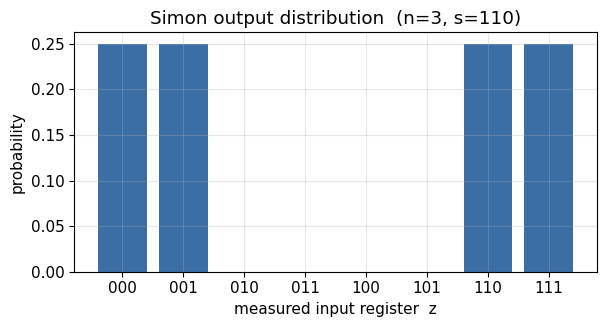

In [7]:
# --- Run it on the n=3, s=110 oracle and confirm the interference pattern ---
marg = simon_marginal(f_demo, n_demo)

print("Every z with non-zero probability must satisfy  z . s = 0 (mod 2):\n")
print("  z     P(z)     z . s (mod 2)")
print("  " + "-" * 34)
for z in range(2 ** n_demo):
    if marg[z] > 1e-12:
        ok = dot_mod2(z, s_demo)
        print(f"  {z:0{n_demo}b}   {marg[z]:.4f}        {ok}   "
              + ("<-- allowed" if ok == 0 else "*** SHOULD NOT APPEAR ***"))

# hard assertion: destructive interference removed all z with z.s = 1
for z in range(2 ** n_demo):
    if marg[z] > 1e-12:
        assert dot_mod2(z, s_demo) == 0
print("\nConfirmed: all z with z.s = 1 were destroyed by interference.")

plt.bar([f"{z:0{n_demo}b}" for z in range(2 ** n_demo)], marg,
        color="#3b6ea5")
plt.ylabel("probability"); plt.xlabel("measured input register  z")
plt.title(f"Simon output distribution  (n={n_demo}, s={s_demo:0{n_demo}b})")
plt.tight_layout(); plt.show()

## 5 · Classical post-processing over $\mathrm{GF}(2)$

Each run gives an equation $z_i\cdot s = 0 \pmod 2$. Stack the measured $z_i$ as rows of a matrix; the secret $s$ lives in its **null space** (mod 2).

* **If the rows span all $n$ dimensions** → the only solution is $s = 0$ → the function was one-to-one.
* **If the rows span an $(n-1)$-dimensional space** → the null space is $1$-dimensional, $\{0, s\}$, and the unique non-zero vector *is* the secret.

We implement Gaussian elimination (reduced row echelon form) over $\mathrm{GF}(2)$ and extract a non-zero null vector. `run_simon` samples runs, stops early if the equations ever reach full rank (signalling $s=0$), and otherwise gathers enough independent equations to pin down $s$.

In [8]:
def gf2_rref(rows, n):
    '''Reduced row echelon form over GF(2). Returns (rref_rows, pivot_columns).'''
    M = [np.array(r, dtype=int) % 2 for r in rows]
    pivots, r = [], 0
    for c in range(n):
        piv = next((i for i in range(r, len(M)) if M[i][c] == 1), None)
        if piv is None:
            continue
        M[r], M[piv] = M[piv], M[r]                 # bring pivot up
        for i in range(len(M)):                     # eliminate this column elsewhere
            if i != r and M[i][c] == 1:
                M[i] = (M[i] + M[r]) % 2
        pivots.append(c); r += 1
        if r == len(M):
            break
    return M[:r], pivots

def gf2_nullspace(rows, n):
    '''A basis for the null space {v : rows . v = 0 (mod 2)}.'''
    R, pivots = gf2_rref(rows, n)
    free = [c for c in range(n) if c not in pivots]
    basis = []
    for fc in free:
        vec = np.zeros(n, dtype=int); vec[fc] = 1
        for i, pc in enumerate(pivots):
            vec[pc] = R[i][fc] % 2
        basis.append(vec)
    return basis

def solve_simon(zs, n):
    '''Given measured z-vectors, return the secret s (as a bit array).
    Returns the all-zero string when the equations have full rank (one-to-one f).'''
    if len(zs) == 0:
        return np.zeros(n, dtype=int)
    _, pivots = gf2_rref(zs, n)
    if len(pivots) == n:                 # equations span everything -> s = 0
        return np.zeros(n, dtype=int)
    for v in gf2_nullspace(zs, n):       # rank n-1 -> unique non-zero null vector
        if v.any():
            return v % 2
    return np.zeros(n, dtype=int)

def run_simon(f, n, rng=RNG, max_rounds=None, verbose=False):
    '''Full Simon routine: sample circuit runs, collect equations, solve for s.
    Returns (recovered_s_bits, list_of_measured_z_bitarrays).'''
    if max_rounds is None:
        max_rounds = max(24, 6 * n)      # generous; also lets us detect s = 0
    marg = simon_marginal(f, n)
    marg = marg / marg.sum()             # guard against tiny numerical drift
    zs = []
    for _ in range(max_rounds):
        z = int(rng.choice(2 ** n, p=marg))     # one circuit run + measurement
        zs.append(int_to_bits(z, n))
        _, pivots = gf2_rref(zs, n)
        if len(pivots) == n:             # full rank early -> function is one-to-one
            break
    s_hat = solve_simon(zs, n)
    if verbose:
        print("  measured z's :", [bits_to_int(z) for z in zs])
        print("  independent equations used :", len(gf2_rref(zs, n)[1]))
    return s_hat, zs

print("GF(2) solver + Simon driver ready.")

GF(2) solver + Simon driver ready.


In [9]:
def demo_simon(n, s, rng=RNG, show_plot=True):
    '''End-to-end demonstration: build oracle, run Simon, recover & verify s.'''
    f = make_simon_function(s, n, rng)
    verify_function(f, s, n)
    marg = simon_marginal(f, n)

    s_hat, zs = run_simon(f, n, rng, verbose=True)
    recovered = bits_to_int(s_hat)

    print(f"\n  true secret s      : {int_to_bits(s, n)}  (= {s}, binary {s:0{n}b})")
    print(f"  recovered secret   : {s_hat}  (= {recovered}, binary {recovered:0{n}b})")
    print("  MATCH " + ("YES" if recovered == s else "NO !!!"))
    assert recovered == s, "recovery failed"

    if show_plot:
        labels = [f"{z:0{n}b}" for z in range(2 ** n)]
        colors = ["#c44e52" if dot_mod2(z, s) else "#3b6ea5"
                  for z in range(2 ** n)]
        plt.bar(labels, marg, color=colors)
        plt.ylabel("probability"); plt.xlabel("measured z")
        plt.title(f"n={n}, s={s:0{n}b}  (blue: z·s=0 survive · red: z·s=1 cancelled)")
        plt.tight_layout(); plt.show()
    return s_hat

print("demo_simon ready.")

demo_simon ready.


## 6 · Case $n = 1$, the degenerate warm-up

With a single qubit the secret is one bit, $s\in\{0,1\}$.

* **$s = 1$:** the function is two-to-one, so it maps $\{0,1\}$ to a single value. Step 1 already makes $\tfrac{1}{\sqrt2}(|0\rangle+|1\rangle)$; the Hadamard in Step 3 turns that back into $|0\rangle$, so **you always measure $z=0$**. The one equation $0\cdot s = 0$ is satisfied by *everything*, so it contributes no constraint. We need $n-1 = 0$ independent equations, none!, and conclude $s$ is the unique non-zero string, $s=1$.
* **$s = 0$:** the function is one-to-one; the output measurement collapses the input to a single basis state, and Step 3 spreads it uniformly, so you get $z\in\{0,1\}$ at random. Seeing a $z=1$ immediately proves the equations reached full rank $\Rightarrow s=0$.

So $n=1$ is *too small to be interesting*, but it makes crystal clear **why Simon needs $n-1$ independent equations.** Watch both sub-cases below.

=== n = 1, secret s = 1 (two-to-one: you should ALWAYS measure z = 0) ===
  measured z's : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  independent equations used : 0

  true secret s      : [1]  (= 1, binary 1)
  recovered secret   : [1]  (= 1, binary 1)
  MATCH YES


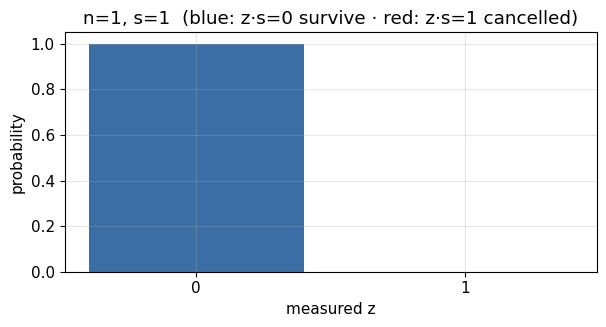


=== n = 1, secret s = 0 (one-to-one: z is a random bit) ===
  measured z's : [1]
  independent equations used : 1

  true secret s      : [0]  (= 0, binary 0)
  recovered secret   : [0]  (= 0, binary 0)
  MATCH YES


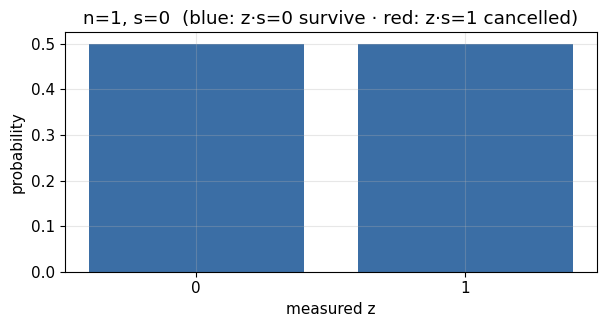

array([0])

In [10]:
print("=== n = 1, secret s = 1 (two-to-one: you should ALWAYS measure z = 0) ===")
demo_simon(n=1, s=1)

print("\n=== n = 1, secret s = 0 (one-to-one: z is a random bit) ===")
demo_simon(n=1, s=0)

## 7 · Case $n = 2$

Now the algorithm does real work. With $s\neq 0$ the allowed outcomes form a $1$-dimensional line $\{z : z\cdot s = 0\}$, so **two** distinct $z$ values survive (including $z=00$). One non-trivial equation is enough to solve for $s$.

===== n = 2, secret s = 01 =====
  measured z's : [2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 0, 2, 2, 0, 0, 2, 0, 0, 0, 2, 2, 2]
  independent equations used : 1

  true secret s      : [1 0]  (= 1, binary 01)
  recovered secret   : [1 0]  (= 1, binary 01)
  MATCH YES


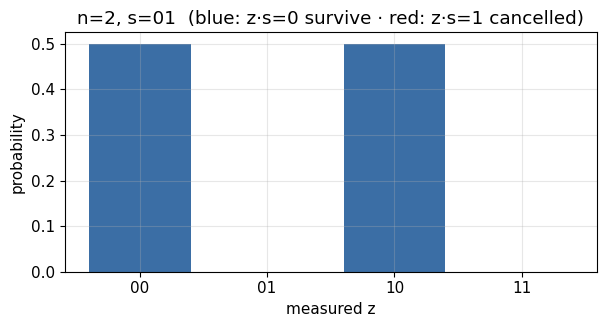


===== n = 2, secret s = 10 =====
  measured z's : [1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1]
  independent equations used : 1

  true secret s      : [0 1]  (= 2, binary 10)
  recovered secret   : [0 1]  (= 2, binary 10)
  MATCH YES


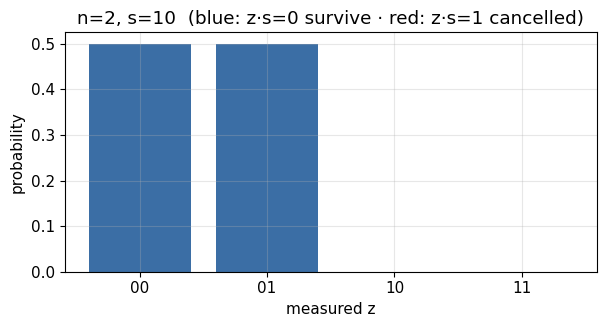


===== n = 2, secret s = 11 =====
  measured z's : [0, 0, 3, 0, 0, 3, 0, 3, 0, 0, 0, 3, 0, 0, 0, 3, 3, 3, 0, 3, 3, 3, 0, 0]
  independent equations used : 1

  true secret s      : [1 1]  (= 3, binary 11)
  recovered secret   : [1 1]  (= 3, binary 11)
  MATCH YES


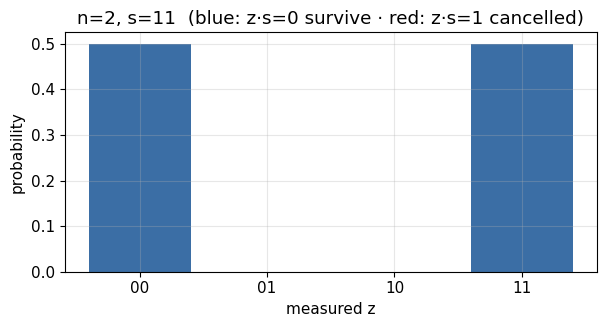

In [11]:
for s in (0b01, 0b10, 0b11):
    print(f"===== n = 2, secret s = {s:02b} =====")
    demo_simon(n=2, s=s)
    print()

## 8 · Case $n = 3$

With $n=3$ the surviving strings form a $2$-dimensional plane ($4$ of the $8$ strings survive), and we need **two** linearly independent equations to fix $s$. Notice in the plots how *exactly half* the strings are wiped out by destructive interference, those are the ones with $z\cdot s = 1$.

===== n = 3, secret s = 001 =====
  measured z's : [4, 0, 6, 6, 4, 2, 4, 4, 4, 0, 2, 0, 2, 2, 0, 0, 4, 0, 6, 4, 2, 4, 0, 6]
  independent equations used : 2

  true secret s      : [1 0 0]  (= 1, binary 001)
  recovered secret   : [1 0 0]  (= 1, binary 001)
  MATCH YES


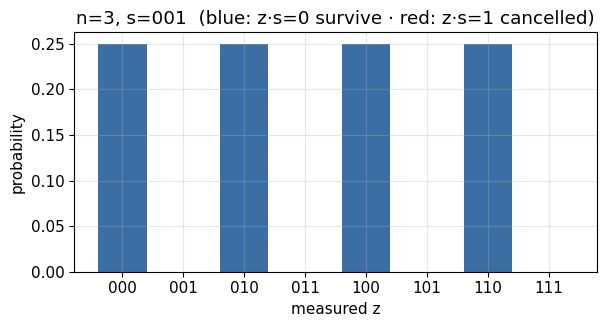


===== n = 3, secret s = 101 =====
  measured z's : [2, 7, 5, 2, 2, 2, 5, 2, 0, 7, 7, 0, 5, 0, 5, 2, 5, 5, 7, 0, 7, 0, 0, 5]
  independent equations used : 2

  true secret s      : [1 0 1]  (= 5, binary 101)
  recovered secret   : [1 0 1]  (= 5, binary 101)
  MATCH YES


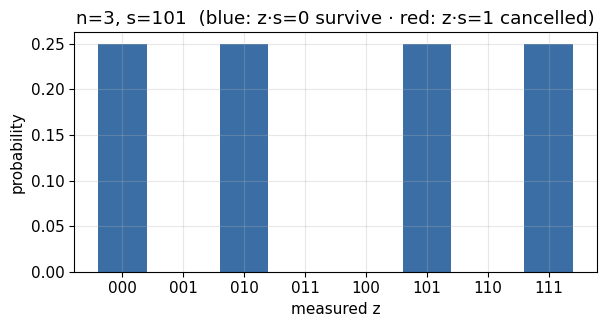


===== n = 3, secret s = 110 =====
  measured z's : [7, 1, 6, 1, 7, 0, 0, 1, 7, 7, 6, 7, 7, 6, 1, 7, 6, 1, 0, 6, 1, 7, 0, 0]
  independent equations used : 2

  true secret s      : [0 1 1]  (= 6, binary 110)
  recovered secret   : [0 1 1]  (= 6, binary 110)
  MATCH YES


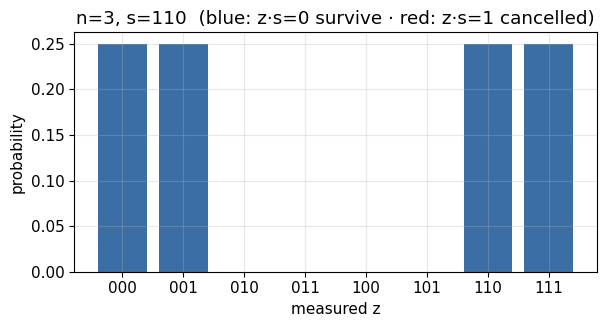


===== n = 3, secret s = 111 =====
  measured z's : [0, 3, 6, 6, 5, 0, 0, 0, 0, 5, 0, 5, 5, 5, 0, 6, 5, 5, 0, 0, 6, 3, 3, 3]
  independent equations used : 2

  true secret s      : [1 1 1]  (= 7, binary 111)
  recovered secret   : [1 1 1]  (= 7, binary 111)
  MATCH YES


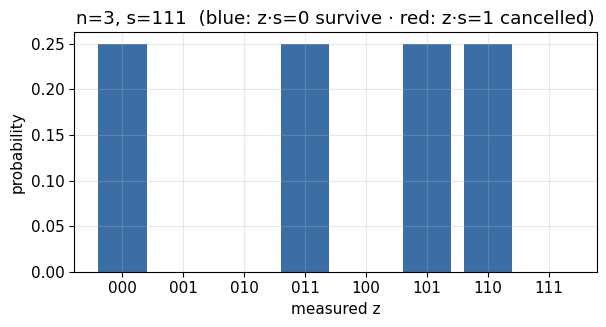

In [12]:
for s in (0b001, 0b101, 0b110, 0b111):
    print(f"===== n = 3, secret s = {s:03b} =====")
    demo_simon(n=3, s=s)
    print()

## 9 · The same algorithm in Qiskit

Everything above was pure NumPy so the physics stayed visible. Now the **framework version**: we build an actual quantum circuit and run it on the Aer simulator.

**The oracle circuit** for a chosen secret `s`:
1. `CX(input_i -> output_i)` for each $i$ copies the input into the output (this alone is the one-to-one $f(x)=x$).
2. Pick any set bit $j$ of $s$ as a control; for every bit $k$ with $s_k=1$, add `CX(input_j -> output_k)`. This folds each coset $\{x, x\oplus s\}$ onto the same output, giving the two-to-one promise.

**Endianness.** Qiskit prints measurement bitstrings **little-endian**, the *rightmost* character is qubit $0$. We convert each bitstring to our LSB-first arrays with `bitstr[-1-j]` = qubit $j$, so the recovered string matches our convention character-for-character.

In [13]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

def simon_oracle_circuit(s_bits, n):
    '''U_f on 2n qubits: 0..n-1 = input, n..2n-1 = output; enforces f(x)=f(x^s).
    s_bits is LSB-first (s_bits[j] is the bit on qubit j).'''
    qc = QuantumCircuit(2 * n, name="U_f")
    for i in range(n):
        qc.cx(i, n + i)                          # copy input -> output
    if np.any(s_bits):
        j = int(np.flatnonzero(np.asarray(s_bits))[0])   # a fixed set bit -> control
        for k in range(n):
            if s_bits[k]:
                qc.cx(j, n + k)                  # fold the coset onto one output
    return qc

def build_simon_circuit(s_bits, n):
    '''Full Simon circuit: H on input, oracle, H on input, measure input.'''
    qc = QuantumCircuit(2 * n, n)
    qc.h(range(n))
    qc.compose(simon_oracle_circuit(s_bits, n), inplace=True)
    qc.barrier()
    qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc

def counts_to_z_arrays(counts, n):
    '''Qiskit little-endian bitstrings -> list of LSB-first z bit arrays.'''
    zs = []
    for bitstr, cnt in counts.items():
        arr = np.array([int(bitstr[-1, j]) for j in range(n)], dtype=int)
        zs.extend([arr] * cnt)
    return zs

# draw the circuit for n = 3, s = 110
demo_circ = build_simon_circuit(int_to_bits(0b110, 3), 3)
print(demo_circ.draw(output="text"))

     ┌───┐                          ░ ┌───┐┌─┐      
q_0: ┤ H ├──■───────────────────────░─┤ H ├┤M├──────
     ├───┤  │                       ░ ├───┤└╥┘┌─┐   
q_1: ┤ H ├──┼────■─────────■────■───░─┤ H ├─╫─┤M├───
     ├───┤  │    │         │    │   ░ ├───┤ ║ └╥┘┌─┐
q_2: ┤ H ├──┼────┼────■────┼────┼───░─┤ H ├─╫──╫─┤M├
     └───┘┌─┴─┐  │    │    │    │   ░ └───┘ ║  ║ └╥┘
q_3: ─────┤ X ├──┼────┼────┼────┼───░───────╫──╫──╫─
          └───┘┌─┴─┐  │  ┌─┴─┐  │   ░       ║  ║  ║ 
q_4: ──────────┤ X ├──┼──┤ X ├──┼───░───────╫──╫──╫─
               └───┘┌─┴─┐└───┘┌─┴─┐ ░       ║  ║  ║ 
q_5: ───────────────┤ X ├─────┤ X ├─░───────╫──╫──╫─
                    └───┘     └───┘ ░       ║  ║  ║ 
c: 3/═══════════════════════════════════════╩══╩══╩═
                                            0  1  2 


In [14]:
AER = AerSimulator()

def run_simon_qiskit(s, n, shots=4096, sim=AER, verbose=True):
    '''Run Simon on Aer, post-process the counts, and recover s.'''
    s_bits = int_to_bits(s, n)
    qc = build_simon_circuit(s_bits, n)
    counts = sim.run(transpile(qc, sim), shots=shots).result().get_counts()

    zs = counts_to_z_arrays(counts, n)
    # keep, as independent equations, the distinct measured strings
    distinct = sorted({bits_to_int(z) for z in zs})
    s_hat = solve_simon([int_to_bits(z, n) for z in distinct], n)
    recovered = bits_to_int(s_hat)
    if verbose:
        print(f"  distinct measured z's : {[f'{z:0{n}b}' for z in distinct]}")
        print(f"  true s = {s:0{n}b}   recovered = {recovered:0{n}b}   "
              + ("MATCH" if recovered == s else "MISMATCH!"))
    assert recovered == s
    return counts, s_hat

print("=== Qiskit Simon, n = 2 ===")
counts2, _ = run_simon_qiskit(0b11, 2)

print("\n=== Qiskit Simon, n = 3 ===")
counts3, _ = run_simon_qiskit(0b110, 3)

=== Qiskit Simon, n = 2 ===
  distinct measured z's : ['00', '11']
  true s = 11   recovered = 11   MATCH

=== Qiskit Simon, n = 3 ===
  distinct measured z's : ['000', '001', '110', '111']
  true s = 110   recovered = 110   MATCH


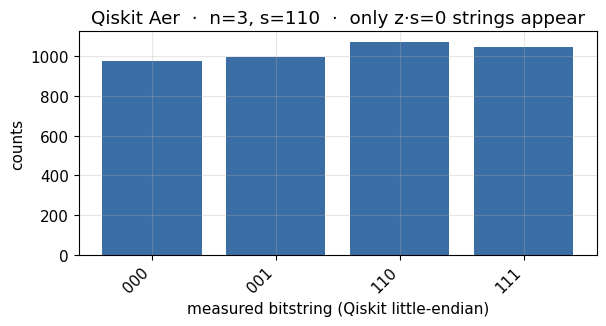

In [15]:
# Histogram of the n = 3 measurement counts (compare with the NumPy plot above)
s3 = 0b110
labels = sorted(counts3, key=lambda b: int(b, 2))
vals = [counts3[b] for b in labels]
# color by z.s parity, reading Qiskit's little-endian string back to an integer
zints = [int(b, 2) for b in labels]   # Qiskit string -> LSB-first integer
colors = ["#c44e52" if dot_mod2(z, s3) else "#3b6ea5" for z in zints]
plt.bar(labels, vals, color=colors)
plt.ylabel("counts"); plt.xlabel("measured bitstring (Qiskit little-endian)")
plt.title(f"Qiskit Aer  ·  n=3, s={s3:03b}  ·  only z·s=0 strings appear")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

## 10 · Shots and noise (a realistic simulation)

On ideal hardware only strings with $z\cdot s = 0$ appear. On **noisy** hardware, gate errors leak a little probability onto the forbidden strings, so some measured equations are *wrong*. The fix in practice: take enough shots, keep the **most frequent / consistent** equations, and cross-check the recovered $s$ against the collected data (or repeat).

Below we add a depolarising noise model and watch a few forbidden strings creep in, yet the correct $s$ is still recoverable from the dominant, self-consistent equations.

In [16]:
from qiskit_aer.noise import NoiseModel, depolarizing_error

noise = NoiseModel()
noise.add_all_qubit_quantum_error(depolarizing_error(0.02, 1), ["h", "x"])
noise.add_all_qubit_quantum_error(depolarizing_error(0.05, 2), ["cx"])
NOISY = AerSimulator(noise_model=noise)

s, n, shots = 0b110, 3, 8192
qc = build_simon_circuit(int_to_bits(s, n), n)
counts = NOISY.run(transpile(qc, NOISY), shots=shots).result().get_counts()

# convert each Qiskit little-endian string to our LSB-first integer with int(b, 2)
bad = sum(c for b, c in counts.items() if dot_mod2(int(b, 2), s) == 1)
print(f"total shots            : {shots}")
print(f"shots on invalid strings (noise-induced) : {bad}"
      f"  (~{100*bad/shots:.1f}%)")

# Robust recovery WITHOUT knowing s: the secret is the non-zero string t that is
# consistent with the most shots, i.e. maximises the count of z with z·t = 0.
# (For the true s almost every clean shot fits; a wrong t fits only about half.)
def score(t):
    return sum(c for b, c in counts.items() if dot_mod2(int(b, 2), t) == 0)

s_hat = max(range(1, 2 ** n), key=score)
print(f"\nmost-consistent secret (majority vote over equations) : {s_hat:0{n}b}  "
      + ("MATCH" if s_hat == s else "MISMATCH"))

total shots            : 8192
shots on invalid strings (noise-induced) : 684  (~8.3%)

most-consistent secret (majority vote over equations) : 110  MATCH


## 11 · Exercises

Work through these to cement the ideas. Each stub is deliberately written to **return an obviously wrong placeholder**, so an unfinished exercise fails loudly instead of pretending to pass. Replace the `TODO`s, then run the checker cell. Solutions are in the collapsible blocks.

Difficulty: ★ (warm-up) → ★★★★ (challenge).

In [17]:
# ===================== EXERCISES (edit the TODO lines) =====================

# --- E1 ★  Parity / equation check -------------------------------------------
# Return True iff candidate secret `s_int` is consistent with ALL measured z's,
# i.e. z . s_int == 0 (mod 2) for every z in `z_ints`.
def e1_consistent(z_ints, s_int):
    return "TODO: replace me"        # <-- obviously wrong placeholder

# --- E2 ★★  Recover a random secret at n = 4 ---------------------------------
# Pick a random NON-ZERO secret on 4 qubits, build the oracle, run Simon,
# and return (true_s_int, recovered_s_int). They must be equal.
def e2_random_n4(rng=np.random.default_rng(0)):
    n = 4
    true_s = -1                       # TODO: draw a random secret in 1..2^n, 1
    recovered = -2                    # TODO: build oracle, run_simon, recover
    return true_s, recovered

# --- E3 ★★★  A different valid oracle ----------------------------------------
# Build a DIFFERENT two-to-one table for secret s (e.g. a different label
# assignment) that still satisfies f[x] == f[x ^ s], and confirm Simon still
# returns s. Return the recovered secret as an integer.
def e3_alt_oracle(s, n, rng=np.random.default_rng(1)):
    return -1                         # TODO

# --- E4 ★★★★  Empirical query count ------------------------------------------
# For n = 3, s = 0b101, estimate over `trials` repetitions the AVERAGE number of
# circuit runs needed until the collected equations first reach rank n-1
# (i.e. enough to pin down s). Return that average (a float).
def e4_avg_runs(trials=300, n=3, s=0b101, rng=np.random.default_rng(2)):
    return -1.0                       # TODO
print("Exercise stubs loaded. Implement them, then run the checker below.")

Exercise stubs loaded. Implement them, then run the checker below.


In [18]:
# ============================ EXERCISE CHECKER ============================
def check_exercises():
    ok = True
    # E1
    try:
        z = [0b110, 0b011]           # both satisfy z.s=0 for s=0b101? check:
        assert e1_consistent([0b110, 0b000], 0b001) in (True, False)
        assert e1_consistent([0b010], 0b101) is True      # 010 . 101 = 0
        assert e1_consistent([0b100], 0b101) is False     # 100 . 101 = 1
        print("E1 ✔")
    except Exception as ex:
        ok = False; print("E1 ✗ not yet:", ex)
    # E2
    try:
        t, r = e2_random_n4()
        assert 1 <= t <= 15 and t == r
        print("E2 ✔  (secret", format(t, "04b"), "recovered)")
    except Exception as ex:
        ok = False; print("E2 ✗ not yet:", ex)
    # E3
    try:
        assert e3_alt_oracle(0b110, 3) == 0b110
        print("E3 ✔")
    except Exception as ex:
        ok = False; print("E3 ✗ not yet:", ex)
    # E4
    try:
        avg = e4_avg_runs()
        assert isinstance(avg, float) and avg > 0
        print(f"E4 ✔  average runs ≈ {avg:.2f}  (theory: a bit above n-1 = 2)")
    except Exception as ex:
        ok = False; print("E4 ✗ not yet:", ex)
    print("\nAll exercises complete!" if ok else "\nKeep going, some are unfinished.")

check_exercises()

E1 ✗ not yet: 
E2 ✗ not yet: 
E3 ✗ not yet: 
E4 ✗ not yet: 

Keep going, some are unfinished.


<details>
<summary><b>Show solutions</b> (try first!)</summary>

```python
# E1
def e1_consistent(z_ints, s_int):
    return all(dot_mod2(z, s_int) == 0 for z in z_ints)

# E2
def e2_random_n4(rng=np.random.default_rng(0)):
    n = 4
    true_s = int(rng.integers(1, 2 ** n))
    f = make_simon_function(true_s, n, rng)
    recovered = bits_to_int(run_simon(f, n, rng)[0])
    return true_s, recovered

# E3 , assign coset labels in a different (e.g. reversed) order
def e3_alt_oracle(s, n, rng=np.random.default_rng(1)):
    N = 2 ** n
    f = -np.ones(N, dtype=int)
    label = N, 1                      # hand out labels from the top down
    for x in range(N):
        if f[x] == -1:
            f[x] = label; f[x ^ s] = label; label -= 1
    verify_function(f, s, n)
    return bits_to_int(run_simon(f, n, rng)[0])

# E4
def e4_avg_runs(trials=300, n=3, s=0b101, rng=np.random.default_rng(2)):
    total = 0
    for _ in range(trials):
        f = make_simon_function(s, n, rng)
        marg = simon_marginal(f, n); marg = marg / marg.sum()
        zs, runs = [], 0
        while True:
            runs += 1
            zs.append(int_to_bits(int(rng.choice(2 ** n, p=marg)), n))
            if len(gf2_rref(zs, n)[1]) >= n, 1:
                break
        total += runs
    return total / trials
```
</details>

## 12 · Interactive playground

Change `n` (1–4) and the secret `s` and watch the surviving-vs-cancelled strings. The static call runs everywhere; the slider version appears when `ipywidgets` is available (e.g. in Colab).

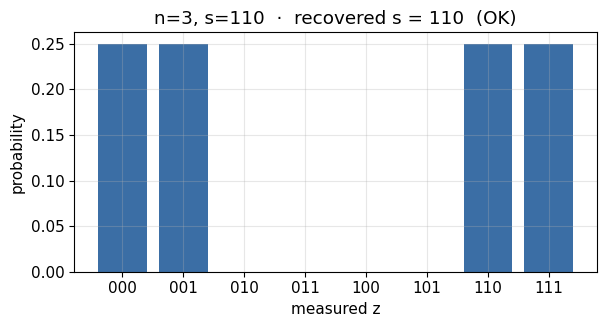

interactive(children=(IntSlider(value=3, description='n', max=4, min=1), IntSlider(value=6, description='secre…

In [20]:
def simon_playground(n=3, s=6):
    n = int(n); s = int(s) % (2 ** n)          # clamp secret into range
    f = make_simon_function(s, n, np.random.default_rng(s + 1))
    marg = simon_marginal(f, n)
    s_hat = bits_to_int(run_simon(f, n, np.random.default_rng(s + 1))[0])
    colors = ["#c44e52" if dot_mod2(z, s) else "#3b6ea5" for z in range(2 ** n)]
    plt.bar([f"{z:0{n}b}" for z in range(2 ** n)], marg, color=colors)
    plt.title(f"n={n}, s={s:0{n}b}  ·  recovered s = {s_hat:0{n}b}  "
              f"({'OK' if s_hat == s else 'check'})")
    plt.ylabel("probability"); plt.xlabel("measured z")
    plt.tight_layout(); plt.show()

# static call, always works
simon_playground(n=3, s=6)

# interactive sliders, appears in a live kernel (Colab/Jupyter)
try:
    from ipywidgets import interact, IntSlider
    interact(simon_playground,
             n=IntSlider(value=3, min=1, max=4, step=1, description="n"),
             s=IntSlider(value=6, min=0, max=15, step=1, description="secret s"))
except Exception as e:
    print("(Interactive sliders unavailable here, call simon_playground(n, s) directly.)")

## 13 · Summary & where this leads

**What we did.** We prepared a uniform superposition, queried the oracle, and applied Hadamards again. Because two inputs $x$ and $x\oplus s$ share an output, *which one occurred is indistinguishable*, so their amplitudes interfere, destructively erasing every string $z$ with $z\cdot s=1$. Each measurement is therefore a free linear equation $z\cdot s\equiv 0\pmod 2$; a handful of them ($n-1$ independent ones) pin down $s$.

**The payoff.**

| | classical | Simon (quantum) |
|---|---|---|
| oracle queries | $\Omega(2^{n/2})$ | $O(n)$ |
| extra work |, | $O(n^3)$ GF(2) solve |

This exponential gap was the **first provable exponential speed-up** for a black-box problem.

**Not parallelism, interference.** The superposition alone does *nothing* useful (measuring it right after Step 1 gives a uniform random string carrying no information about $s$). The advantage appears only when the oracle correlates inputs with outputs and the second Hadamard makes indistinguishable paths interfere. This is the recurring lesson of the whole course.

**Where it goes next.** Simon's problem is the *hidden-subgroup problem* over $(\mathbb{Z}_2)^n$. Replacing that group with $\mathbb{Z}_N$ turns "find the hidden XOR-period $s$" into "find the hidden **period** of a function", which is exactly **Shor's algorithm** for factoring, with the final Hadamard replaced by the **Quantum Fourier Transform**. Simon is the conceptual seed of Shor.

**Now make it yours.** Try: larger $n$; comparing ideal vs. noisy recovery; a majority-vote scheme for noisy equations; or timing how the classical collision search blows up as $n$ grows while Simon stays linear.